# XRF Data Preview

This notebook demonstrates how to use the `XRFSimulator` utility to generate synthetic XRF spectra for different materials.

In [ ]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from src.common.spectrum_utils import XRFSimulator, ATOM_SYMS

['H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne', 'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca', 'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn', 'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y', 'Zr', 'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn', 'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd', 'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb', 'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg', 'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac', 'Th', 'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm', 'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds', 'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og']


## Initialize Simulator
We use a Molybdenum (Mo) target with a tube potential of 30 keV.

In [7]:
sim = XRFSimulator(target="Mo", kvp=30)
print(f"Simulator initialized with target: {sim.target}, energy: {sim.kvp} keV")

Simulator initialized with target: Mo, energy: 30 keV


## Simulate a Sample
Let's simulate a sample containing Iron (Fe) and Copper (Cu).

(600,) (600,)


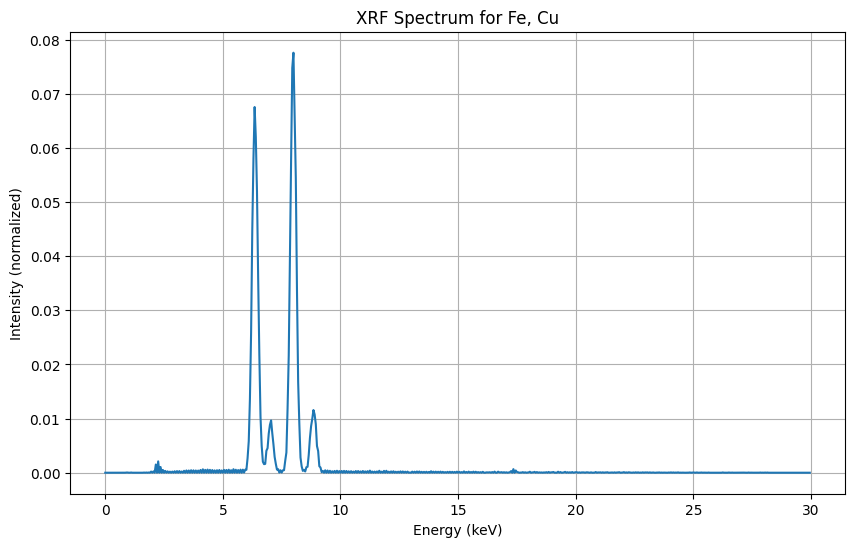

In [ ]:
elements = ['Fe', 'Cu']
spectrum, peaks, els, params = sim.simulate_xrf_spectrum(elements, decal=True, plot=False)

energies = np.arange(0, 30, 0.05)
plt.figure(figsize=(10, 6))
plt.plot(energies, spectrum)
plt.title(f"XRF Spectrum for {', '.join(elements)}")
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity (normalized)")
plt.grid(True)
plt.show()

## Exploring Different Targets
The anode target material affects the primary spectrum.

55.845

(600,) (600,)
(600,) (600,)
(600,) (600,)


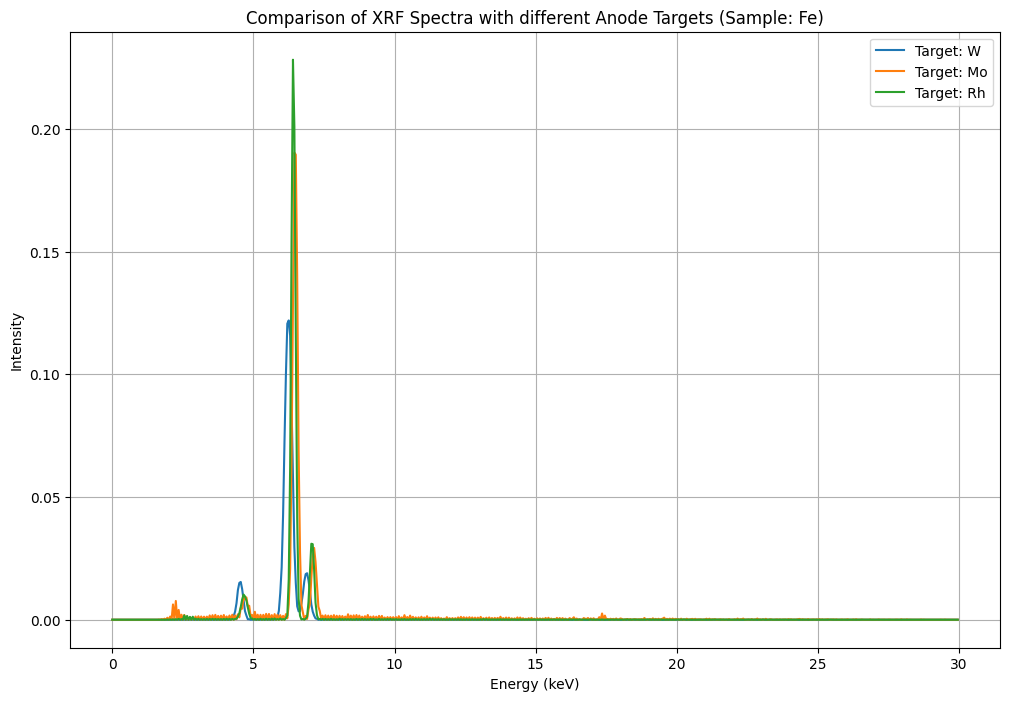

In [5]:
targets = ["W", "Mo", "Rh"]
plt.figure(figsize=(12, 8))

for target in targets:
    sim_target = XRFSimulator(target=target, kvp=30)
    spectrum, _, _, _ = sim_target.simulate_xrf_spectrum(['Fe'], decal=True)
    plt.plot(energies, spectrum, label=f"Target: {target}")

plt.title("Comparison of XRF Spectra with different Anode Targets (Sample: Fe)")
plt.xlabel("Energy (keV)")
plt.ylabel("Intensity")
plt.legend()
plt.grid(True)
plt.show()